# Background-masked CLS token for synthetic 80 m Procrustes

This experiment tests whether a DINOv2 CLS token becomes more useful for Orthogonal Procrustes when visible background context is removed before encoding.

The object remains in its original position and at its original pixel size inside a fixed 640×640 canvas. Pixels outside the ground-truth bounding box are replaced by a constant neutral value. This preserves the 30 m versus synthetic-80 m scale change while preventing the CLS token from seeing sea texture, wakes, nearby people, or other scene content.

```text
fixed-canvas image + object box
             ↓ replace all pixels outside the box
neutral canvas containing only object pixels
             ↓ frozen DINOv2-small
384-dimensional CLS token
             ↓ validation-selected subspace R
corrected 384-dimensional feature
             ↓ fixed classifier trained only on masked real-30 m CLS features
prediction
```

The encoder is frozen. No classifier is trained on synthetic 80 m data. The strict object-disjoint protocol uses 1,010 pairs to fit the mapping, 180 pairs to select its subspace, and 275 pairs for final testing. Every paired object is excluded from training the 30 m classifier.


In [1]:
from pathlib import Path
import json
import os
import random
import warnings
from dataclasses import dataclass


def find_repo_root(start=Path.cwd()):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the repository.")


REPO_ROOT = find_repo_root()
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import joblib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel

SEED = 42
MODEL_NAME = "facebook/dinov2-small"
CANVAS_SIDE = 640
CANVAS_FILL = (114, 114, 114)
BATCH_SIZE = 32
NUM_WORKERS = 0
CANDIDATE_DIMENSIONS = [4, 8, 16, 24, 32, 48, 64, 96, 128, 192, 256, 320, 384]

SOURCE_MANIFEST = REPO_ROOT / "data/splits/seadronessee/seadronessee_25_35m_object_split.csv"
SYNTHETIC_MANIFEST = REPO_ROOT / "data/synthetic/seadronessee_30m_to_80m/manifests/paired_manifest.csv"
BASELINE_PROBE = REPO_ROOT / "results/seadronessee_30m/linear_probe_30m.joblib"
ATTENTION_SUMMARY = REPO_ROOT / "results/seadronessee_attention_object_tokens/strict_unseen_summary.json"
FEATURE_ROOT = REPO_ROOT / "data/features/seadronessee/dinov2_small_masked_cls"
RESULT_ROOT = REPO_ROOT / "results/seadronessee_masked_cls"
FEATURE_ROOT.mkdir(parents=True, exist_ok=True)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Feature cache:", FEATURE_ROOT)
print("Results:", RESULT_ROOT)


Device: cpu
Feature cache: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\data\features\seadronessee\dinov2_small_masked_cls
Results: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_masked_cls


## 1. Load manifests and fixed class definition

In [2]:
objects = pd.read_csv(SOURCE_MANIFEST)
pairs = pd.read_csv(SYNTHETIC_MANIFEST)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    baseline_artifact = joblib.load(BASELINE_PROBE)

class_names = list(baseline_artifact["class_names"])
label_to_index = dict(baseline_artifact["label_to_index"])
selected_c = float(baseline_artifact["selected_C"])

assert objects.object_key.is_unique
assert pairs.pair_id.is_unique
assert set(pairs.object_key).issubset(set(objects.object_key))
print("Real 30 m objects:", len(objects))
print("Synthetic pairs:", len(pairs))
display(pairs.groupby(["split", "category_name"]).size().unstack(fill_value=0))


Real 30 m objects: 3307
Synthetic pairs: 1465


category_name,boat,buoy,jetski,swimmer
split,,,,
test,37,2,9,227
train,126,49,9,826
val,19,3,16,142


## 2. Remove visible background before CLS extraction

In [3]:
def fixed_canvas_crop_with_bbox(image, bbox, side=CANVAS_SIDE, fill=CANVAS_FILL):
    x, y, width, height = map(float, bbox)
    center_x = x + width / 2
    center_y = y + height / 2
    left = int(round(center_x - side / 2))
    top = int(round(center_y - side / 2))
    source_left = max(0, left)
    source_top = max(0, top)
    source_right = min(image.width, left + side)
    source_bottom = min(image.height, top + side)
    canvas = Image.new("RGB", (side, side), fill)
    if source_right > source_left and source_bottom > source_top:
        region = image.crop((source_left, source_top, source_right, source_bottom))
        canvas.paste(region, (source_left - left, source_top - top))
    return canvas, (x - left, y - top, width, height)


def mask_outside_bbox(image, bbox, fill=CANVAS_FILL):
    # Retain object-box pixels and replace every other visible pixel.
    x, y, width, height = map(float, bbox)
    left = int(np.floor(np.clip(x, 0, image.width)))
    top = int(np.floor(np.clip(y, 0, image.height)))
    right = int(np.ceil(np.clip(x + width, 0, image.width)))
    bottom = int(np.ceil(np.clip(y + height, 0, image.height)))
    masked = Image.new("RGB", image.size, fill)
    if right > left and bottom > top:
        masked.paste(image.crop((left, top, right, bottom)), (left, top))
    return masked


class MaskedCLSDataset(Dataset):
    def __init__(self, frame, kind, path_column=None):
        self.frame = frame.reset_index(drop=True)
        self.kind = kind
        self.path_column = path_column

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        if self.kind == "real30":
            with Image.open(REPO_ROOT / Path(str(row.image_path))) as opened:
                canvas, bbox = fixed_canvas_crop_with_bbox(
                    opened.convert("RGB"),
                    (row.bbox_x, row.bbox_y, row.bbox_width, row.bbox_height),
                )
        else:
            with Image.open(REPO_ROOT / Path(str(row[self.path_column]))) as opened:
                canvas = opened.convert("RGB")
            bbox = (
                row.synthetic_bbox_x,
                row.synthetic_bbox_y,
                row.synthetic_bbox_width,
                row.synthetic_bbox_height,
            )
        masked = mask_outside_bbox(canvas, bbox)
        pixels = processor(images=masked, return_tensors="pt")["pixel_values"].squeeze(0)
        return pixels, index


In [4]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME, local_files_only=True)
encoder = AutoModel.from_pretrained(MODEL_NAME, local_files_only=True).to(DEVICE)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)
assert sum(parameter.numel() for parameter in encoder.parameters() if parameter.requires_grad) == 0
print("Frozen model:", MODEL_NAME)
print("CLS feature dimension:", encoder.config.hidden_size)


Frozen model: facebook/dinov2-small
CLS feature dimension: 384


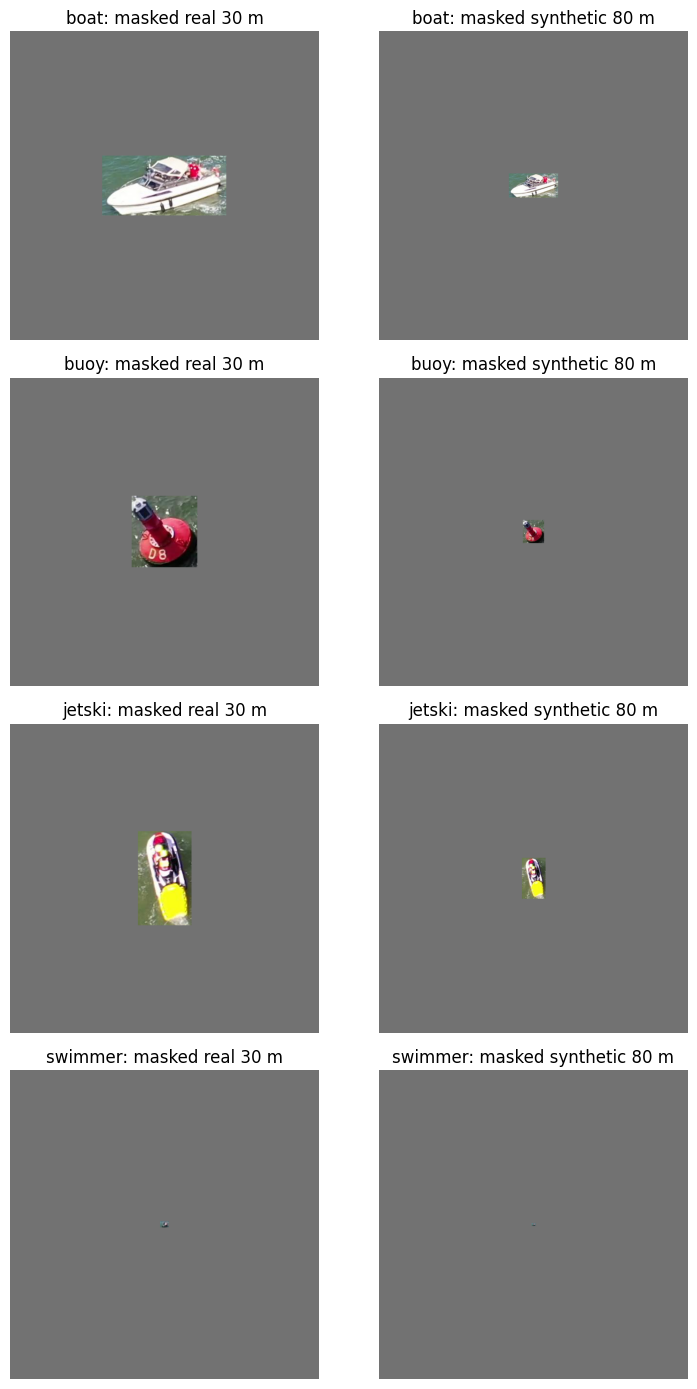

In [5]:
# Visual audit: masking removes context while preserving object pixel size.
examples = []
for class_name in class_names:
    row = pairs[pairs.category_name == class_name].iloc[0]
    object_row = objects.loc[objects.object_key == row.object_key].iloc[0]
    with Image.open(REPO_ROOT / Path(str(object_row.image_path))) as opened:
        real_canvas, real_bbox = fixed_canvas_crop_with_bbox(
            opened.convert("RGB"),
            (object_row.bbox_x, object_row.bbox_y, object_row.bbox_width, object_row.bbox_height),
        )
    with Image.open(REPO_ROOT / Path(str(row.geometry_image_path))) as opened:
        synthetic_canvas = opened.convert("RGB")
    synthetic_bbox = (
        row.synthetic_bbox_x,
        row.synthetic_bbox_y,
        row.synthetic_bbox_width,
        row.synthetic_bbox_height,
    )
    examples.append(
        (
            class_name,
            mask_outside_bbox(real_canvas, real_bbox),
            mask_outside_bbox(synthetic_canvas, synthetic_bbox),
        )
    )

figure, axes = plt.subplots(len(examples), 2, figsize=(8, 3.5 * len(examples)))
for row_index, (class_name, real_image, synthetic_image) in enumerate(examples):
    axes[row_index, 0].imshow(real_image)
    axes[row_index, 0].set_title(f"{class_name}: masked real 30 m")
    axes[row_index, 1].imshow(synthetic_image)
    axes[row_index, 1].set_title(f"{class_name}: masked synthetic 80 m")
    for axis in axes[row_index]:
        axis.axis("off")
figure.tight_layout()
mask_examples_path = RESULT_ROOT / "masked_cls_input_examples.png"
figure.savefig(mask_examples_path, dpi=180, bbox_inches="tight")
plt.show()


## 3. Extract and cache masked CLS features

In [6]:
@torch.inference_mode()
def extract_masked_cls_features(frame, kind, cache_name, path_column=None):
    cache_path = FEATURE_ROOT / f"{cache_name}.npz"
    id_column = "object_key" if kind == "real30" else "pair_id"
    expected_ids = np.asarray(frame[id_column].astype(str).tolist(), dtype=np.str_)
    if cache_path.is_file():
        cached = np.load(cache_path, allow_pickle=False)
        if np.array_equal(cached["ids"].astype(str), expected_ids):
            print("Loaded cache:", cache_path.name)
            return cached["features"].astype(np.float32)

    dataset = MaskedCLSDataset(frame, kind, path_column)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    batches = []
    indices = []
    for pixels, batch_indices in tqdm(loader, desc=cache_name):
        output = encoder(pixel_values=pixels.to(DEVICE))
        features = F.normalize(output.last_hidden_state[:, 0, :].float(), dim=1)
        batches.append(features.cpu().numpy())
        indices.append(batch_indices.numpy())
    features = np.concatenate(batches)
    order = np.argsort(np.concatenate(indices))
    features = features[order].astype(np.float32)
    np.savez_compressed(cache_path, features=features, ids=expected_ids)
    print("Saved cache:", cache_path.name, features.shape)
    return features


objects_ordered = objects.sort_values("object_key").reset_index(drop=True)
pairs_ordered = pairs.sort_values(["split", "pair_id"]).reset_index(drop=True)
X_real_all = extract_masked_cls_features(objects_ordered, "real30", "real30_all")
X_geometry_all = extract_masked_cls_features(
    pairs_ordered, "synthetic", "synthetic_geometry_all", "geometry_image_path"
)
X_calibrated_all = extract_masked_cls_features(
    pairs_ordered, "synthetic", "synthetic_calibrated_all", "calibrated_image_path"
)
print("Feature matrices:", X_real_all.shape, X_geometry_all.shape, X_calibrated_all.shape)


Loaded cache: real30_all.npz
Loaded cache: synthetic_geometry_all.npz
Loaded cache: synthetic_calibrated_all.npz
Feature matrices: (3307, 384) (1465, 384) (1465, 384)


## 4. Strict object-disjoint 30 m probe

In [7]:
real_lookup = {key: X_real_all[index] for index, key in enumerate(objects_ordered.object_key)}
synthetic_index = {pair_id: index for index, pair_id in enumerate(pairs_ordered.pair_id)}


def real_matrix(frame):
    return np.stack([real_lookup[key] for key in frame.object_key]).astype(np.float32)


def synthetic_matrix(frame, all_features):
    return np.stack([all_features[synthetic_index[key]] for key in frame.pair_id]).astype(np.float32)


def labels_for(frame):
    return frame.category_name.map(label_to_index).to_numpy(dtype=np.int64)


train_pairs = pairs[pairs.split == "train"].sort_values("pair_id").reset_index(drop=True)
validation_pairs = pairs[pairs.split == "val"].sort_values("pair_id").reset_index(drop=True)
test_pairs = pairs[pairs.split == "test"].sort_values("pair_id").reset_index(drop=True)

X30_train = real_matrix(train_pairs)
X30_validation = real_matrix(validation_pairs)
X30_test = real_matrix(test_pairs)
Xg_train = synthetic_matrix(train_pairs, X_geometry_all)
Xg_validation = synthetic_matrix(validation_pairs, X_geometry_all)
Xg_test = synthetic_matrix(test_pairs, X_geometry_all)
Xc_train = synthetic_matrix(train_pairs, X_calibrated_all)
Xc_validation = synthetic_matrix(validation_pairs, X_calibrated_all)
Xc_test = synthetic_matrix(test_pairs, X_calibrated_all)
y_train = labels_for(train_pairs)
y_validation = labels_for(validation_pairs)
y_test = labels_for(test_pairs)

# Exclude every object that has a synthetic counterpart from classifier training.
all_pair_keys = set(pairs.object_key)
probe_frame = objects[~objects.object_key.isin(all_pair_keys)].copy()
assert set(probe_frame.object_key).isdisjoint(all_pair_keys)
X_probe = real_matrix(probe_frame)
y_probe = labels_for(probe_frame)

fixed_probe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=selected_c,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    ),
)
fixed_probe.fit(X_probe, y_probe)
print("Strict probe training objects:", len(probe_frame))
print("Mapping train / validation / test:", len(train_pairs), len(validation_pairs), len(test_pairs))
display(probe_frame.category_name.value_counts().reindex(class_names, fill_value=0))


Strict probe training objects: 1842
Mapping train / validation / test: 1010 180 275


category_name
boat       606
buoy       182
jetski      98
swimmer    956
Name: count, dtype: int64

## 5. Validation-selected subspace Orthogonal Procrustes

In [8]:
@dataclass(frozen=True)
class SubspaceMap:
    basis: np.ndarray
    R: np.ndarray

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        coordinates = X @ self.basis
        residual = X - coordinates @ self.basis.T
        return residual + (coordinates @ self.R) @ self.basis.T

    @property
    def orthogonality_error(self):
        identity = np.eye(self.basis.shape[0])
        projection = self.basis @ self.basis.T
        full_map = identity - projection + self.basis @ self.R @ self.basis.T
        return float(np.linalg.norm(full_map.T @ full_map - identity))


def fit_basis(A, B, weights=None):
    if weights is None:
        weights = np.ones(len(A))
    root = np.sqrt(np.asarray(weights) / np.mean(weights))[:, None]
    _, _, Vt = np.linalg.svd(np.vstack([A * root, B * root]), full_matrices=False)
    return Vt.T


def fit_subspace(A, B, basis, k, weights=None):
    selected_basis = basis[:, :k]
    projected_A = A @ selected_basis
    projected_B = B @ selected_basis
    if weights is None:
        U, _, Vt = np.linalg.svd(projected_A.T @ projected_B, full_matrices=False)
    else:
        root = np.sqrt(np.asarray(weights) / np.mean(weights))[:, None]
        U, _, Vt = np.linalg.svd(
            (projected_A * root).T @ (projected_B * root), full_matrices=False
        )
    return SubspaceMap(selected_basis, U @ Vt)


def metrics(probe, X, y, target):
    prediction = probe.predict(X)
    rmse = float(np.sqrt(np.mean((X - target) ** 2)))
    cosine = float(
        np.mean(
            np.sum(X * target, axis=1)
            / (np.linalg.norm(X, axis=1) * np.linalg.norm(target, axis=1))
        )
    )
    return {
        "accuracy": accuracy_score(y, prediction),
        "balanced_accuracy": balanced_accuracy_score(y, prediction),
        "macro_f1": f1_score(
            y,
            prediction,
            labels=np.arange(len(class_names)),
            average="macro",
            zero_division=0,
        ),
        "rmse": rmse,
        "paired_cosine": cosine,
    }


variant_data = {
    "geometry": {"train": Xg_train, "validation": Xg_validation, "test": Xg_test},
    "calibrated": {"train": Xc_train, "validation": Xc_validation, "test": Xc_test},
}
class_counts = train_pairs.category_name.value_counts()
class_weights = train_pairs.category_name.map(lambda name: 1 / class_counts[name]).to_numpy()

zero_rows = []
for partition, y_part, target, key in [
    ("validation", y_validation, X30_validation, "validation"),
    ("test", y_test, X30_test, "test"),
]:
    for variant, data in variant_data.items():
        zero_rows.append(
            {
                "partition": partition,
                "variant": variant,
                **metrics(fixed_probe, data[key], y_part, target),
            }
        )
zero = pd.DataFrame(zero_rows)
display(zero)

validation_rows = []
fitted_maps = {}
for variant, data in variant_data.items():
    for weighting in ["unweighted", "class_balanced"]:
        weights = None if weighting == "unweighted" else class_weights
        basis = fit_basis(data["train"], X30_train, weights)
        raw = zero[
            (zero.partition == "validation") & (zero.variant == variant)
        ].iloc[0]
        for dimension in CANDIDATE_DIMENSIONS:
            fitted = fit_subspace(
                data["train"], X30_train, basis, dimension, weights
            )
            result = metrics(
                fixed_probe,
                fitted.transform(data["validation"]),
                y_validation,
                X30_validation,
            )
            validation_rows.append(
                {
                    "variant": variant,
                    "weighting": weighting,
                    "dimension": dimension,
                    "orthogonality_error": fitted.orthogonality_error,
                    **result,
                    "macro_f1_change": result["macro_f1"] - raw["macro_f1"],
                    "cosine_change": result["paired_cosine"] - raw["paired_cosine"],
                    "rmse_change": result["rmse"] - raw["rmse"],
                }
            )
            fitted_maps[(variant, weighting, dimension)] = fitted

validation_results = pd.DataFrame(validation_rows)
validation_results["passes_gate"] = (
    (validation_results.macro_f1_change > 0)
    & (validation_results.cosine_change > 0)
    & (validation_results.rmse_change < 0)
)
validation_results.to_csv(RESULT_ROOT / "validation_results.csv", index=False)
print("Validation gate passes:", validation_results.passes_gate.sum(), "of", len(validation_results))


,partition,variant,accuracy,balanced_accuracy,macro_f1,rmse,paired_cosine
0,validation,geometry,0.788889,0.319322,0.310155,0.030228,0.824565
1,validation,calibrated,0.794444,0.332480,0.338028,0.030254,0.824267
2,test,geometry,0.858182,0.513659,0.504204,0.034959,0.765347
3,test,calibrated,0.858182,0.513659,0.506667,0.035013,0.764621


Validation gate passes: 52 of 52


## 6. Select on validation and evaluate once on test

In [9]:
selected_rows = []
test_rows = []
selected_maps = {}
for variant in ["geometry", "calibrated"]:
    candidates = validation_results[validation_results.variant == variant]
    passing = candidates[candidates.passes_gate]
    pool = passing if len(passing) else candidates
    chosen = pool.sort_values(["macro_f1", "paired_cosine"], ascending=False).iloc[0]
    fitted = fitted_maps[(variant, str(chosen.weighting), int(chosen.dimension))]
    raw = zero[(zero.partition == "test") & (zero.variant == variant)].iloc[0]
    result = metrics(
        fixed_probe,
        fitted.transform(variant_data[variant]["test"]),
        y_test,
        X30_test,
    )
    selected_rows.append(
        {
            "variant": variant,
            "weighting": chosen.weighting,
            "dimension": int(chosen.dimension),
            "selection_status": (
                "passed_validation_gate" if len(passing) else "diagnostic_only_no_gate_pass"
            ),
            "validation_macro_f1": chosen.macro_f1,
            "validation_cosine": chosen.paired_cosine,
        }
    )
    test_rows.append(
        {
            "variant": variant,
            "weighting": chosen.weighting,
            "dimension": int(chosen.dimension),
            **result,
            "macro_f1_change": result["macro_f1"] - raw["macro_f1"],
            "cosine_change": result["paired_cosine"] - raw["paired_cosine"],
            "rmse_change": result["rmse"] - raw["rmse"],
            "passes_test_gate": bool(
                result["macro_f1"] > raw["macro_f1"]
                and result["paired_cosine"] > raw["paired_cosine"]
                and result["rmse"] < raw["rmse"]
            ),
        }
    )
    selected_maps[variant] = fitted

selected = pd.DataFrame(selected_rows)
test_results = pd.DataFrame(test_rows)
selected.to_csv(RESULT_ROOT / "selected_models.csv", index=False)
test_results.to_csv(RESULT_ROOT / "test_results.csv", index=False)
print("Selected on validation:")
display(selected)
print("Held-out synthetic test:")
display(test_results)


Selected on validation:


,variant,weighting,dimension,selection_status,validation_macro_f1,validation_cosine
0,geometry,unweighted,48,passed_validation_gate,0.581651,0.897764
1,calibrated,unweighted,64,passed_validation_gate,0.648107,0.895221


Held-out synthetic test:


,variant,weighting,dimension,accuracy,balanced_accuracy,macro_f1,rmse,paired_cosine,macro_f1_change,cosine_change,rmse_change,passes_test_gate
0,geometry,unweighted,48,0.967273,0.608908,0.630914,0.028112,0.848267,0.126711,0.082920,-0.006847,True
1,calibrated,unweighted,64,0.956364,0.668668,0.686487,0.028143,0.847930,0.179820,0.083309,-0.006870,True


## 7. Confusion matrices and per-class metrics

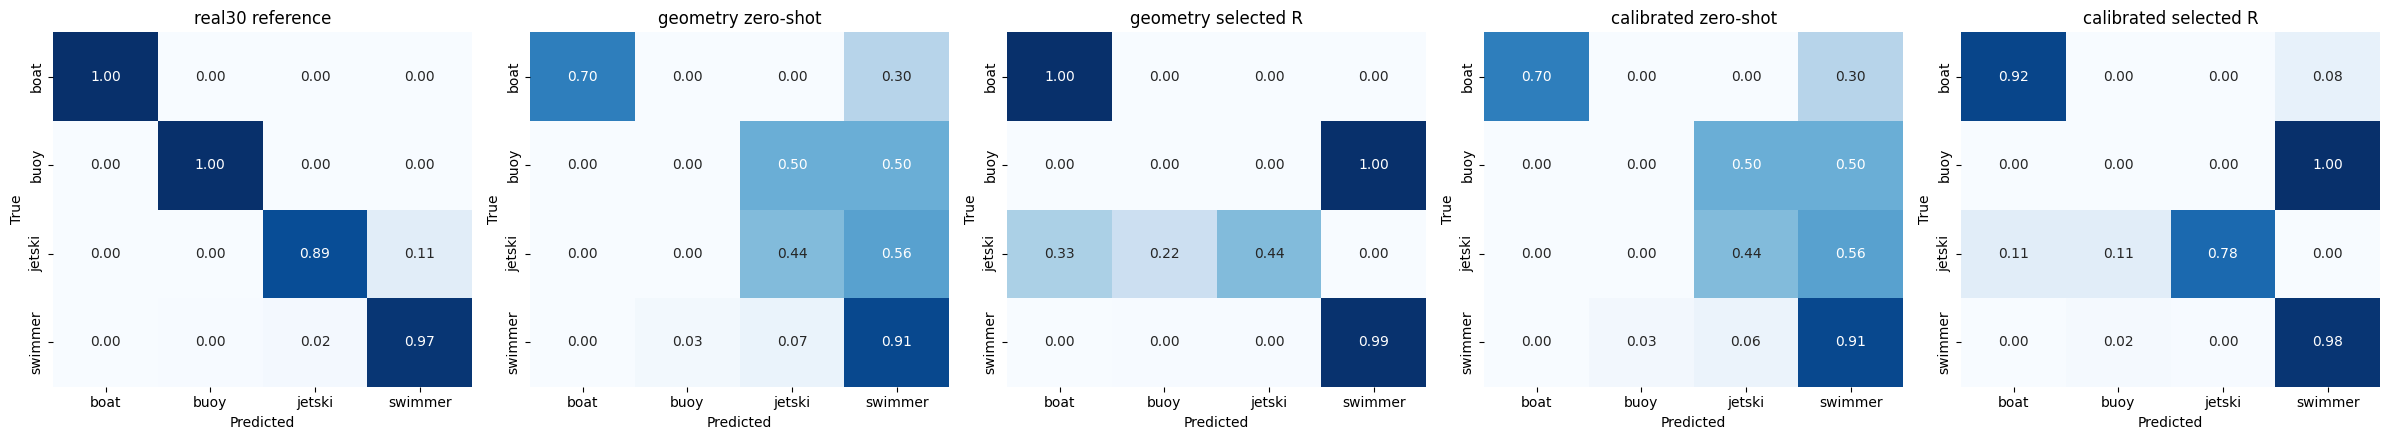

f1  precision  recall  support
evaluation            class                                      
calibrated selected R boat     0.9444     0.9714  0.9189     37.0
                      buoy     0.0000     0.0000  0.0000      2.0
                      jetski   0.8235     0.8750  0.7778      9.0
                      swimmer  0.9780     0.9780  0.9780    227.0
calibrated zero-shot  boat     0.8254     1.0000  0.7027     37.0
                      buoy     0.0000     0.0000  0.0000      2.0
                      jetski   0.2857     0.2105  0.4444      9.0
                      swimmer  0.9156     0.9238  0.9075    227.0
geometry selected R   boat     0.9610     0.9250  1.0000     37.0
                      buoy     0.0000     0.0000  0.0000      2.0
                      jetski   0.5714     0.8000  0.4444      9.0
                      swimmer  0.9912     0.9912  0.9912    227.0
geometry zero-shot    boat     0.8254     1.0000  0.7027     37.0
                      buoy     0.0000     0.0000  0.0000      2.0
                      jetski   0.2759     0.2000  0.4444      9.0
                      swimmer  0.9156     0.9238  0.9075    227.0
real30 reference      boat     1.0000     1.0000  1.0000     37.0
                      buoy     0.8000     0.6667  1.0000      2.0
                      jetski   0.7273     0.6154  0.8889      9.0
                      swimmer  0.9844     0.9955  0.9736    227.0

In [10]:
predictions = {
    "real30 reference": fixed_probe.predict(X30_test),
    "geometry zero-shot": fixed_probe.predict(Xg_test),
    "geometry selected R": fixed_probe.predict(selected_maps["geometry"].transform(Xg_test)),
    "calibrated zero-shot": fixed_probe.predict(Xc_test),
    "calibrated selected R": fixed_probe.predict(selected_maps["calibrated"].transform(Xc_test)),
}

figure, axes = plt.subplots(1, len(predictions), figsize=(24, 4.5))
per_class_rows = []
for axis, (name, prediction) in zip(axes, predictions.items()):
    matrix = confusion_matrix(
        y_test,
        prediction,
        labels=np.arange(len(class_names)),
        normalize="true",
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        ax=axis,
    )
    axis.set_title(name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        prediction,
        labels=np.arange(len(class_names)),
        zero_division=0,
    )
    for index, class_name in enumerate(class_names):
        per_class_rows.append(
            {
                "evaluation": name,
                "class": class_name,
                "precision": precision[index],
                "recall": recall[index],
                "f1": f1[index],
                "support": int(support[index]),
            }
        )

figure.tight_layout()
confusion_path = RESULT_ROOT / "masked_cls_test_confusions.png"
figure.savefig(confusion_path, dpi=180, bbox_inches="tight")
plt.show()

per_class = pd.DataFrame(per_class_rows)
per_class.to_csv(RESULT_ROOT / "per_class_metrics.csv", index=False)
display(per_class.pivot_table(index=["evaluation", "class"], values=["precision", "recall", "f1", "support"]).round(4))


## 8. Compare with attention-weighted object tokens

In [11]:
attention_summary = json.loads(ATTENTION_SUMMARY.read_text(encoding="utf-8"))
attention_zero = pd.DataFrame(attention_summary["zero_shot"])
attention_test = pd.DataFrame(attention_summary["test_results"])

comparison_rows = []
for representation, zero_frame, result_frame in [
    ("background-masked CLS", zero, test_results),
    ("attention-weighted object tokens", attention_zero, attention_test),
]:
    for variant in ["geometry", "calibrated"]:
        raw = zero_frame[
            (zero_frame.partition == "test") & (zero_frame.variant == variant)
        ].iloc[0]
        corrected = result_frame[result_frame.variant == variant].iloc[0]
        comparison_rows.append(
            {
                "representation": representation,
                "variant": variant,
                "zero_shot_macro_f1": raw.macro_f1,
                "corrected_macro_f1": corrected.macro_f1,
                "macro_f1_improvement": corrected.macro_f1 - raw.macro_f1,
                "balanced_accuracy": corrected.balanced_accuracy,
                "selected_dimension": int(corrected.dimension),
                "passes_test_gate": bool(corrected.passes_test_gate),
            }
        )

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(RESULT_ROOT / "masked_cls_vs_attention_comparison.csv", index=False)
display(comparison)


,representation,variant,zero_shot_macro_f1,corrected_macro_f1,macro_f1_improvement,balanced_accuracy,selected_dimension,passes_test_gate
0,background-masked CLS,geometry,0.504204,0.630914,0.126711,0.608908,48,True
1,background-masked CLS,calibrated,0.506667,0.686487,0.179820,0.668668,64,True
2,attention-weighted object tokens,geometry,0.703147,0.786032,0.082885,0.840614,24,True
3,attention-weighted object tokens,calibrated,0.703147,0.769912,0.066765,0.840614,24,True


## 9. Save reproducible artifacts

In [12]:
map_records = {}
for variant, fitted in selected_maps.items():
    row = selected[selected.variant == variant].iloc[0]
    prefix = f"masked_cls_{variant}_{row.weighting}_k{int(row.dimension)}"
    np.save(RESULT_ROOT / f"{prefix}_basis.npy", fitted.basis)
    np.save(RESULT_ROOT / f"{prefix}_R.npy", fitted.R)
    map_records[variant] = {
        "weighting": str(row.weighting),
        "dimension": int(row.dimension),
        "basis": fitted.basis,
        "R": fitted.R,
        "orthogonality_error": fitted.orthogonality_error,
    }

joblib.dump(
    {
        "model_name": MODEL_NAME,
        "representation": "CLS_from_bbox_pixels_on_constant_640_canvas",
        "mapping_direction": "synthetic_80m_to_real_30m",
        "fixed_30m_probe": fixed_probe,
        "selected_maps": map_records,
        "class_names": class_names,
        "canvas_fill": CANVAS_FILL,
    },
    RESULT_ROOT / "masked_cls_procrustes_bundle.joblib",
)

summary = {
    "experiment": "background_masked_cls_procrustes",
    "representation": "CLS_from_bbox_pixels_on_constant_640_canvas",
    "probe_training_objects": len(probe_frame),
    "mapping_train_pairs": len(train_pairs),
    "validation_pairs": len(validation_pairs),
    "test_pairs": len(test_pairs),
    "zero_shot": zero.to_dict("records"),
    "selected": selected.to_dict("records"),
    "test_results": test_results.to_dict("records"),
    "comparison_with_attention_tokens": comparison.to_dict("records"),
}
(RESULT_ROOT / "masked_cls_summary.json").write_text(
    json.dumps(summary, indent=2) + "\n", encoding="utf-8"
)
print("Saved masked-CLS experiment to:", RESULT_ROOT)


Saved masked-CLS experiment to: C:\Users\ADMIN\Desktop\fastr\uav-altitude-feature-alignment\results\seadronessee_masked_cls


## Interpretation limits

- The visible background is replaced with a constant, but the CLS token still encodes object size, location, the mask boundary, and the constant canvas. “Object-only” therefore means object pixels without natural scene context; it is not a guarantee of perfectly pure semantic features.
- Ground-truth boxes are supplied. This is cropped-object classification rather than full-image detection.
- Rank and weighting are selected on validation data. Only the selected mappings are evaluated on the test set.
- The final claim depends on macro-F1 and feature-alignment metrics on held-out synthetic objects. Genuine 80 m multi-class evaluation remains necessary.


## Observed outcome

Background masking made the CLS representation more responsive to Procrustes correction, but it did not outperform attention-weighted patch tokens.

| Representation | Variant | Zero-shot macro-F1 | Corrected macro-F1 | Change from R | Selected subspace | Test gate |
|---|---|---:|---:|---:|---:|---|
| Background-masked CLS | Geometry | 0.5042 | **0.6309** | +0.1267 | 48 | Passed |
| Background-masked CLS | Calibrated | 0.5073 | **0.6865** | +0.1792 | 64 | Passed |
| Attention-weighted object tokens | Geometry | 0.7031 | **0.7860** | +0.0829 | 24 | Passed |
| Attention-weighted object tokens | Calibrated | 0.7031 | **0.7699** | +0.0668 | 24 | Passed |

For calibrated masked CLS, balanced accuracy increased from 0.5148 to 0.6687, paired cosine similarity increased from 0.7646 to 0.8479, and paired RMSE decreased from 0.03501 to 0.02814. The mapping therefore improved both classification and paired feature alignment. Its corrected class recall was 0.92 for boats, 0.00 for buoys, 0.78 for jet skis, and 0.98 for swimmers. Only two buoys occur in the test set, but neither was recovered.

The experiment supports two conclusions. First, natural background context was one source of difficulty for the global CLS representation: removing it produced a stronger corrected result than the earlier global-CLS experiment. Second, completely replacing the surrounding scene with a constant makes tiny objects occupy very little of the CLS input and removes context that can help recognition. Attention-weighted patch pooling provides the better balance in this dataset and remains the preferred representation.

The masking is strict only outside the bounding box. Pixels inside a rectangular annotation can still include water surrounding the object. Pixel-level removal would require segmentation masks, which are not provided for this experiment.
